# Individual Differences in Predictability

**Purpose**: Investigate why some subjects are highly predictable (~90% accuracy) while others are near chance. Correlate subject-level predictability with behavioral traits.

**Key Questions**:
1. What is the distribution of subject-level prediction accuracy?
2. Who are the highly predictable vs. unpredictable subjects?
3. Do behavioral traits (RT variability, choice consistency, ambiguity sensitivity) explain predictability?
4. Are there distinct "types" of decision-makers?

**Why This Matters**:
- Understanding individual differences helps identify who benefits most from physiological monitoring
- Reveals whether predictability reflects decision style, data quality, or both
- Informs personalized BCI/neurofeedback applications

In [1]:
import sys
sys.path.append('../..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
OUTPUT_DIR = Path('../../data/results/main/statistical_analyses/individual_differences')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"{'='*70}")
print(f"INDIVIDUAL DIFFERENCES IN PREDICTABILITY")
print(f"{'='*70}")
print(f"Analysis started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

INDIVIDUAL DIFFERENCES IN PREDICTABILITY
Analysis started: 2026-04-17 12:06:52


## 1. Load Data

In [2]:
# Load extracted features
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
gaze_cols = feature_data['gaze_cols']
behavior_cols = feature_data['behavior_cols']

# Create combined physio+gaze feature set
physio_gaze_cols = physio_cols + gaze_cols

print(f"Loaded {len(merged_df)} trials from {merged_df['subject_id'].nunique()} subjects")
print(f"\nFeature counts:")
print(f"  Physio (pupil): {len(physio_cols)}")
print(f"  Gaze: {len(gaze_cols)}")
print(f"  Behavior: {len(behavior_cols)}")
print(f"  Total physio+gaze: {len(physio_gaze_cols)}")

Loaded 12107 trials from 102 subjects

Feature counts:
  Physio (pupil): 13
  Gaze: 20
  Behavior: 11
  Total physio+gaze: 33


## 2. Compute Subject-Level Prediction Accuracy

In [3]:
def get_subject_prediction_accuracy(df, feature_cols, feature_name='features'):
    """
    Run LOSO-CV and return per-subject accuracy.
    """
    logo = LeaveOneGroupOut()
    imputer = SimpleImputer(strategy='mean')
    scaler = StandardScaler()
    
    X = df[feature_cols].values
    y = df['outcome'].values
    subjects = df['subject_id'].values
    
    subject_results = []
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        subj = subjects[test_idx[0]]
        
        # Preprocess
        X_train = imputer.fit_transform(X_train)
        X_test = imputer.transform(X_test)
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        # Train and predict
        clf = RandomForestClassifier(n_estimators=100, max_depth=5, 
                                     class_weight='balanced', random_state=42, n_jobs=-1)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1]
        
        acc = accuracy_score(y_test, y_pred)
        
        # AUC (handle single class)
        if len(np.unique(y_test)) > 1:
            auc = roc_auc_score(y_test, y_prob)
        else:
            auc = np.nan
        
        subject_results.append({
            'subject_id': subj,
            f'{feature_name}_accuracy': acc,
            f'{feature_name}_auc': auc,
            'n_trials': len(y_test),
            'invest_rate': y_test.mean()
        })
    
    return pd.DataFrame(subject_results)

print("Computing subject-level prediction accuracies...")
print("(This may take a few minutes)\n")

# Physio+Gaze combined
print("Running Physio+Gaze prediction...")
physio_gaze_results = get_subject_prediction_accuracy(merged_df, physio_gaze_cols, 'physio_gaze')

# Behavior only (for comparison)
print("Running Behavior prediction...")
behavior_results = get_subject_prediction_accuracy(merged_df, behavior_cols, 'behavior')

# Merge results
subject_acc_df = physio_gaze_results.merge(
    behavior_results[['subject_id', 'behavior_accuracy', 'behavior_auc']], 
    on='subject_id'
)

print(f"\nComputed accuracies for {len(subject_acc_df)} subjects")

Computing subject-level prediction accuracies...
(This may take a few minutes)

Running Physio+Gaze prediction...
Running Behavior prediction...

Computed accuracies for 102 subjects


In [4]:
# Distribution of subject-level accuracy
print("\n" + "="*70)
print("DISTRIBUTION OF SUBJECT-LEVEL PREDICTION ACCURACY")
print("="*70)

print(f"\nPhysio+Gaze Accuracy:")
print(f"  Mean: {subject_acc_df['physio_gaze_accuracy'].mean():.3f}")
print(f"  Std:  {subject_acc_df['physio_gaze_accuracy'].std():.3f}")
print(f"  Min:  {subject_acc_df['physio_gaze_accuracy'].min():.3f}")
print(f"  Max:  {subject_acc_df['physio_gaze_accuracy'].max():.3f}")
print(f"  Range: {subject_acc_df['physio_gaze_accuracy'].max() - subject_acc_df['physio_gaze_accuracy'].min():.3f}")

# Categorize subjects
subject_acc_df['predictability_group'] = pd.cut(
    subject_acc_df['physio_gaze_accuracy'],
    bins=[0, 0.55, 0.65, 0.75, 1.0],
    labels=['Near Chance (<55%)', 'Low (55-65%)', 'Medium (65-75%)', 'High (>75%)']
)

print(f"\nPredictability Groups:")
print(subject_acc_df['predictability_group'].value_counts().sort_index())


DISTRIBUTION OF SUBJECT-LEVEL PREDICTION ACCURACY

Physio+Gaze Accuracy:
  Mean: 0.603
  Std:  0.161
  Min:  0.209
  Max:  1.000
  Range: 0.791

Predictability Groups:
predictability_group
Near Chance (<55%)    38
Low (55-65%)          23
Medium (65-75%)       24
High (>75%)           17
Name: count, dtype: int64


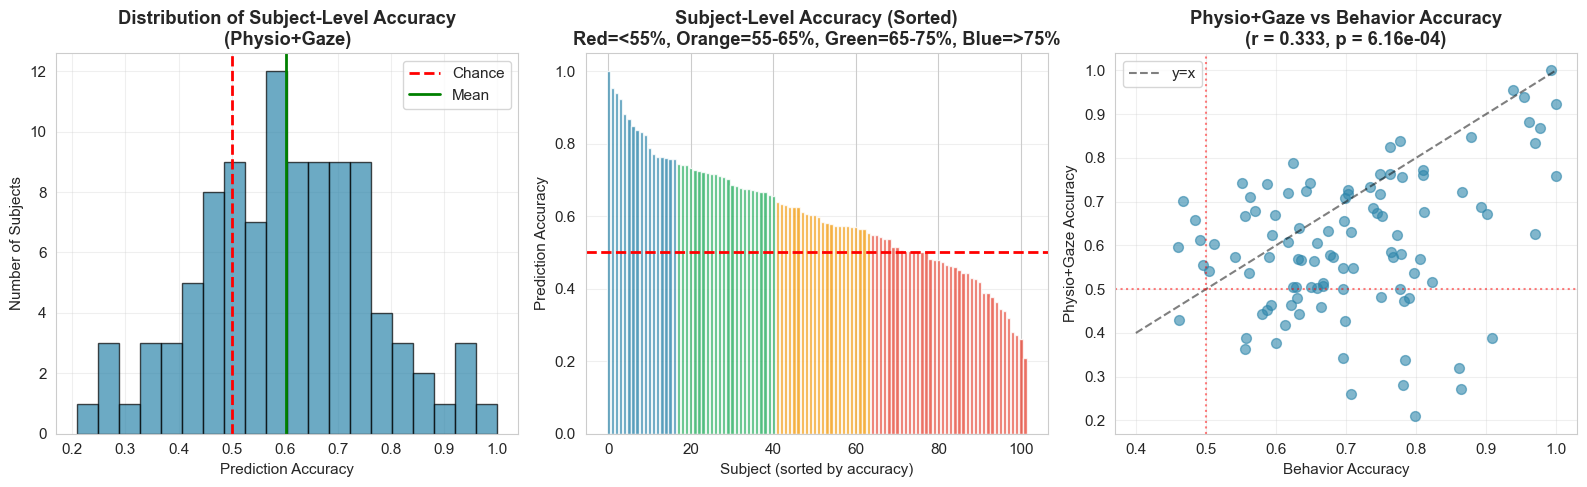

In [5]:
# Visualization: Distribution of subject-level accuracy
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Histogram
ax = axes[0]
ax.hist(subject_acc_df['physio_gaze_accuracy'], bins=20, color='#2E86AB', alpha=0.7, edgecolor='black')
ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Chance')
ax.axvline(subject_acc_df['physio_gaze_accuracy'].mean(), color='green', linestyle='-', linewidth=2, label='Mean')
ax.set_xlabel('Prediction Accuracy')
ax.set_ylabel('Number of Subjects')
ax.set_title('Distribution of Subject-Level Accuracy\n(Physio+Gaze)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Sorted bar chart
ax = axes[1]
sorted_df = subject_acc_df.sort_values('physio_gaze_accuracy', ascending=False)
colors = ['#E74C3C' if acc < 0.55 else '#F39C12' if acc < 0.65 else '#27AE60' if acc < 0.75 else '#2E86AB' 
          for acc in sorted_df['physio_gaze_accuracy']]
ax.bar(range(len(sorted_df)), sorted_df['physio_gaze_accuracy'], color=colors, alpha=0.8)
ax.axhline(0.5, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Subject (sorted by accuracy)')
ax.set_ylabel('Prediction Accuracy')
ax.set_title('Subject-Level Accuracy (Sorted)\nRed=<55%, Orange=55-65%, Green=65-75%, Blue=>75%', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Physio+Gaze vs Behavior accuracy
ax = axes[2]
ax.scatter(subject_acc_df['behavior_accuracy'], subject_acc_df['physio_gaze_accuracy'], 
           c='#2E86AB', alpha=0.6, s=50)
ax.plot([0.4, 1], [0.4, 1], 'k--', alpha=0.5, label='y=x')
ax.axhline(0.5, color='red', linestyle=':', alpha=0.5)
ax.axvline(0.5, color='red', linestyle=':', alpha=0.5)
r, p = stats.pearsonr(subject_acc_df['behavior_accuracy'], subject_acc_df['physio_gaze_accuracy'])
ax.set_xlabel('Behavior Accuracy')
ax.set_ylabel('Physio+Gaze Accuracy')
ax.set_title(f'Physio+Gaze vs Behavior Accuracy\n(r = {r:.3f}, p = {p:.2e})', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'subject_accuracy_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Compute Behavioral Traits for Each Subject

In [6]:
# Compute subject-level behavioral traits using behavior features from the pickle
print("\n" + "="*70)
print("COMPUTING BEHAVIORAL TRAITS PER SUBJECT")
print("="*70)

print(f"\nBehavior features available: {behavior_cols}")

subject_traits = []

for subj in merged_df['subject_id'].unique():
    subj_df = merged_df[merged_df['subject_id'] == subj]
    
    # Basic stats
    n_trials = len(subj_df)
    invest_rate = subj_df['outcome'].mean()
    
    # === RT statistics (from behavior features) ===
    rt_mean = subj_df['decision_time'].mean()
    rt_std = subj_df['decision_time'].std()
    rt_cv = rt_std / rt_mean if rt_mean > 0 else np.nan  # Coefficient of variation
    rt_median = subj_df['decision_time'].median()
    
    # === Use behavior features from pickle ===
    # EV difference variability - how variable are their EV differences across trials
    ev_diff_mean = subj_df['ev_difference'].mean()
    ev_diff_std = subj_df['ev_difference'].std()
    
    # Risk premium variability
    risk_premium_mean = subj_df['risk_premium'].mean()
    risk_premium_std = subj_df['risk_premium'].std()
    
    # Investment variance sensitivity (average across trials)
    invest_variance_mean = subj_df['invest_variance'].mean()
    
    # Sequential behavior features (averaged per subject)
    running_invest_rate_mean = subj_df['running_invest_rate'].mean()
    running_invest_rate_std = subj_df['running_invest_rate'].std()
    recent_invest_rate_std = subj_df['recent_invest_rate_5'].std()  # Variability in recent choices
    
    # === Derived behavioral traits ===
    # Choice consistency - how often do they make the same choice for similar ambiguity?
    choice_consistency = []
    for amb in [0, 3, 6]:
        amb_df = subj_df[subj_df['ambiguity'] == amb]
        if len(amb_df) > 1:
            # Consistency = how far from 50% is their invest rate
            consistency = abs(amb_df['outcome'].mean() - 0.5) * 2  # Ranges 0-1
            choice_consistency.append(consistency)
    mean_choice_consistency = np.mean(choice_consistency) if choice_consistency else np.nan
    
    # Ambiguity sensitivity - how much does ambiguity affect choice?
    low_amb_invest = subj_df[subj_df['ambiguity'] == 0]['outcome'].mean()
    high_amb_invest = subj_df[subj_df['ambiguity'] == 6]['outcome'].mean()
    ambiguity_sensitivity = abs(low_amb_invest - high_amb_invest) if not np.isnan(low_amb_invest) and not np.isnan(high_amb_invest) else np.nan
    
    # RT by choice - do they deliberate more for one choice?
    invest_rt = subj_df[subj_df['outcome'] == 1]['decision_time'].mean()
    keep_rt = subj_df[subj_df['outcome'] == 0]['decision_time'].mean()
    rt_choice_diff = invest_rt - keep_rt if not np.isnan(invest_rt) and not np.isnan(keep_rt) else np.nan
    
    # Social condition proportion
    social_prop = subj_df['condition_social'].mean()
    
    # === Physiological variability ===
    pupil_mean_var = subj_df['pupil_mean_pre'].std() if 'pupil_mean_pre' in subj_df.columns else np.nan
    gaze_x_std_var = subj_df['gaze_x_std'].std() if 'gaze_x_std' in subj_df.columns else np.nan
    
    subject_traits.append({
        'subject_id': subj,
        'n_trials': n_trials,
        'subject_invest_rate': invest_rate,  # Renamed to avoid conflict
        # RT features
        'rt_mean': rt_mean,
        'rt_std': rt_std,
        'rt_cv': rt_cv,
        'rt_median': rt_median,
        'rt_choice_diff': rt_choice_diff,
        # Behavior features from pickle
        'ev_diff_mean': ev_diff_mean,
        'ev_diff_std': ev_diff_std,
        'risk_premium_mean': risk_premium_mean,
        'risk_premium_std': risk_premium_std,
        'invest_variance_mean': invest_variance_mean,
        'social_prop': social_prop,
        # Sequential behavior
        'running_invest_rate_std': running_invest_rate_std,
        'recent_invest_rate_std': recent_invest_rate_std,
        # Derived traits
        'choice_consistency': mean_choice_consistency,
        'ambiguity_sensitivity': ambiguity_sensitivity,
        # Physiological variability
        'pupil_variability': pupil_mean_var,
        'gaze_variability': gaze_x_std_var
    })

traits_df = pd.DataFrame(subject_traits)
print(f"\nComputed {len(traits_df.columns)-1} traits for {len(traits_df)} subjects")
print(f"\nTraits: {list(traits_df.columns[1:])}")


COMPUTING BEHAVIORAL TRAITS PER SUBJECT

Behavior features available: ['decision_time', 'ev_difference', 'invest_variance', 'ambiguity', 'condition_social', 'risk_premium', 'running_invest_rate', 'recent_invest_rate_5', 'prev_outcome', 'trial_position', 'consecutive_same']

Computed 19 traits for 102 subjects

Traits: ['n_trials', 'subject_invest_rate', 'rt_mean', 'rt_std', 'rt_cv', 'rt_median', 'rt_choice_diff', 'ev_diff_mean', 'ev_diff_std', 'risk_premium_mean', 'risk_premium_std', 'invest_variance_mean', 'social_prop', 'running_invest_rate_std', 'recent_invest_rate_std', 'choice_consistency', 'ambiguity_sensitivity', 'pupil_variability', 'gaze_variability']


In [7]:
# Merge traits with accuracy (drop duplicate invest_rate from subject_acc_df)
subject_acc_clean = subject_acc_df.drop(columns=['invest_rate'], errors='ignore')
analysis_df = subject_acc_clean.merge(traits_df, on='subject_id')

print(f"\nMerged dataset: {len(analysis_df)} subjects")
print(f"\nTrait summary statistics:")
print(analysis_df[['rt_cv', 'choice_consistency', 'ambiguity_sensitivity', 'subject_invest_rate']].describe().round(3))


Merged dataset: 102 subjects

Trait summary statistics:
         rt_cv  choice_consistency  ambiguity_sensitivity  subject_invest_rate
count  102.000             102.000                102.000              102.000
mean     0.283               0.537                  0.378                0.652
std      0.053               0.235                  0.279                0.178
min      0.186               0.055                  0.000                0.255
25%      0.249               0.354                  0.140                0.523
50%      0.270               0.526                  0.336                0.627
75%      0.307               0.686                  0.583                0.795
max      0.426               1.000                  1.000                1.000


## 4. Correlate Predictability with Behavioral Traits

In [8]:
print("\n" + "="*70)
print("CORRELATIONS: PREDICTABILITY vs BEHAVIORAL TRAITS")
print("="*70)

# Use all behavioral traits computed from behavior features
trait_cols = ['rt_mean', 'rt_std', 'rt_cv', 'rt_choice_diff',
              'ev_diff_mean', 'ev_diff_std', 'risk_premium_mean', 'risk_premium_std',
              'invest_variance_mean', 'social_prop',
              'running_invest_rate_std', 'recent_invest_rate_std',
              'choice_consistency', 'ambiguity_sensitivity', 'subject_invest_rate',
              'pupil_variability', 'gaze_variability', 'n_trials']

correlations = []
print("\nCorrelations with Physio+Gaze prediction accuracy:")
print("-" * 60)

for trait in trait_cols:
    if trait not in analysis_df.columns:
        continue
    valid = analysis_df[['physio_gaze_accuracy', trait]].dropna()
    if len(valid) > 10:
        r, p = stats.pearsonr(valid['physio_gaze_accuracy'], valid[trait])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f"  {trait:25s}: r = {r:+.3f}, p = {p:.3e} {sig}")
        correlations.append({'trait': trait, 'r': r, 'p': p, 'n': len(valid)})

corr_df = pd.DataFrame(correlations).sort_values('p')
print("\n" + "-" * 60)
print("Top predictors of subject-level accuracy (sorted by p-value):")
print(corr_df.head(5).to_string(index=False))


CORRELATIONS: PREDICTABILITY vs BEHAVIORAL TRAITS

Correlations with Physio+Gaze prediction accuracy:
------------------------------------------------------------
  rt_mean                  : r = -0.444, p = 2.953e-06 ***
  rt_std                   : r = -0.392, p = 4.543e-05 ***
  rt_cv                    : r = +0.059, p = 5.570e-01 
  rt_choice_diff           : r = -0.181, p = 7.478e-02 
  ev_diff_mean             : r = -0.153, p = 1.245e-01 
  ev_diff_std              : r = +0.131, p = 1.901e-01 
  risk_premium_mean        : r = -0.136, p = 1.737e-01 
  risk_premium_std         : r = -0.011, p = 9.144e-01 
  invest_variance_mean     : r = +0.156, p = 1.167e-01 
  social_prop              : r = +0.132, p = 1.864e-01 
  running_invest_rate_std  : r = -0.081, p = 4.203e-01 
  recent_invest_rate_std   : r = -0.275, p = 5.193e-03 **
  choice_consistency       : r = +0.358, p = 2.187e-04 ***
  ambiguity_sensitivity    : r = +0.084, p = 4.013e-01 
  subject_invest_rate      : r = +0.153, 

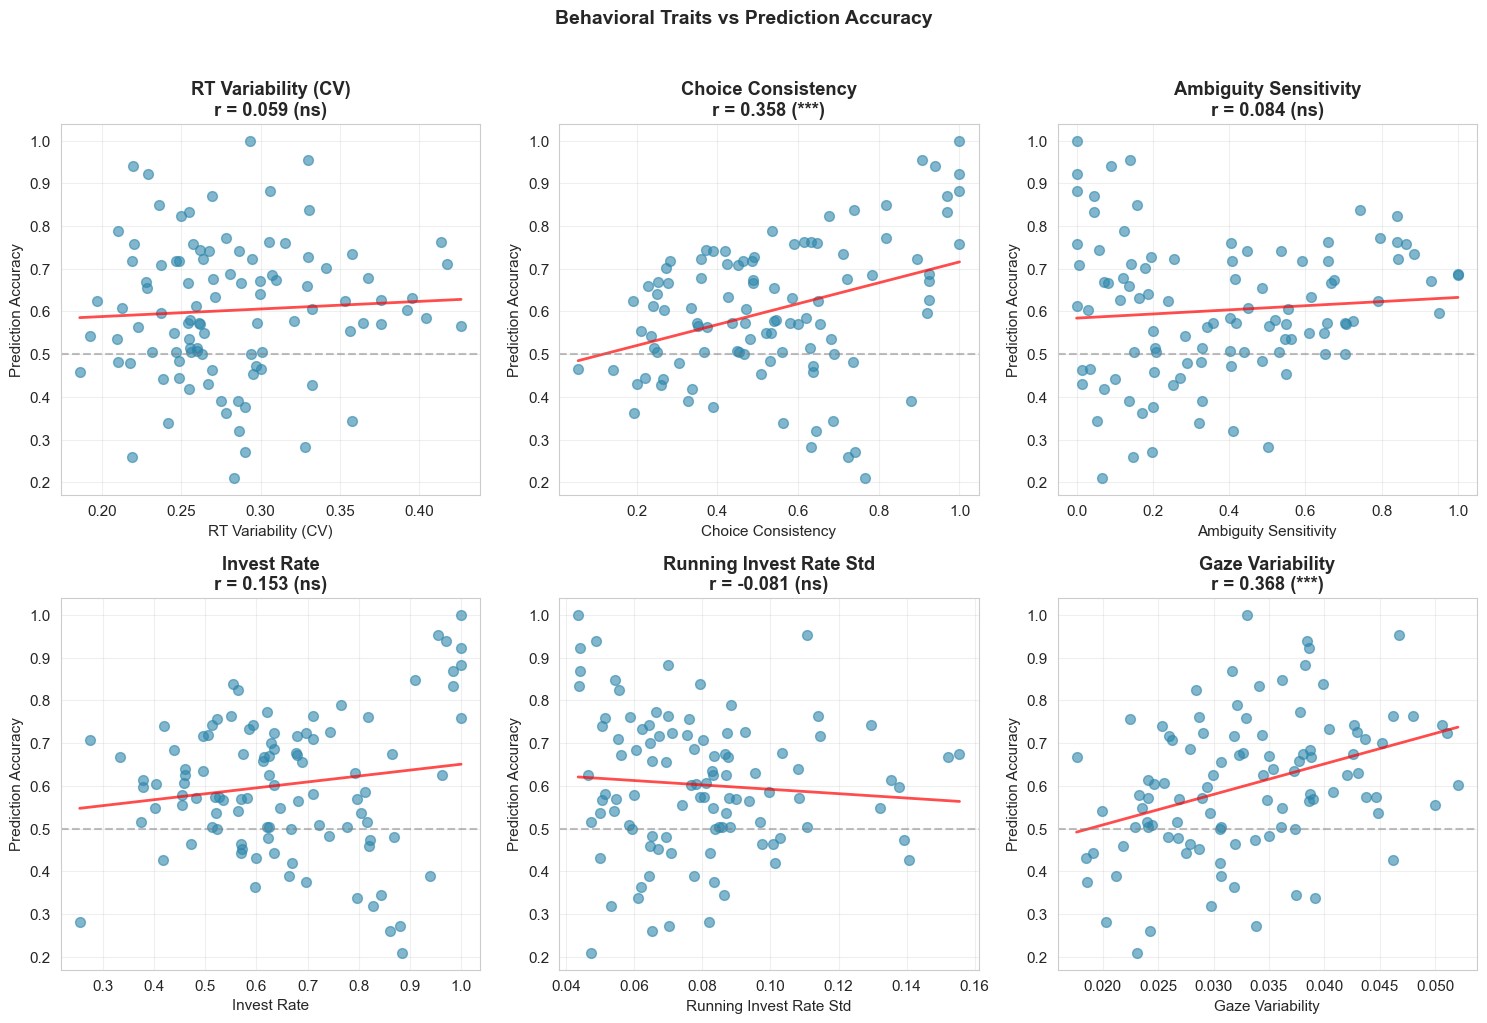

In [9]:
# Visualization: Key correlations (select top traits for visualization)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Select key traits to visualize
key_traits = ['rt_cv', 'choice_consistency', 'ambiguity_sensitivity', 
              'subject_invest_rate', 'running_invest_rate_std', 'gaze_variability']
trait_labels = ['RT Variability (CV)', 'Choice Consistency', 'Ambiguity Sensitivity',
                'Invest Rate', 'Running Invest Rate Std', 'Gaze Variability']

for idx, (trait, label) in enumerate(zip(key_traits, trait_labels)):
    ax = axes[idx // 3, idx % 3]
    
    if trait not in analysis_df.columns:
        ax.set_visible(False)
        continue
        
    valid = analysis_df[['physio_gaze_accuracy', trait]].dropna()
    
    ax.scatter(valid[trait], valid['physio_gaze_accuracy'], 
               c='#2E86AB', alpha=0.6, s=50)
    
    # Add regression line
    if len(valid) > 10:
        z = np.polyfit(valid[trait], valid['physio_gaze_accuracy'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(valid[trait].min(), valid[trait].max(), 100)
        ax.plot(x_line, p(x_line), 'r-', alpha=0.7, linewidth=2)
        
        r, pval = stats.pearsonr(valid[trait], valid['physio_gaze_accuracy'])
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
        ax.set_title(f'{label}\nr = {r:.3f} ({sig})', fontweight='bold')
    
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel(label)
    ax.set_ylabel('Prediction Accuracy')
    ax.grid(True, alpha=0.3)

plt.suptitle('Behavioral Traits vs Prediction Accuracy', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'traits_vs_predictability.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Characterize High vs Low Predictability Subjects

In [10]:
print("\n" + "="*70)
print("COMPARING HIGH vs LOW PREDICTABILITY SUBJECTS")
print("="*70)

# Define high and low predictability groups (top/bottom quartile)
q75 = analysis_df['physio_gaze_accuracy'].quantile(0.75)
q25 = analysis_df['physio_gaze_accuracy'].quantile(0.25)

high_pred = analysis_df[analysis_df['physio_gaze_accuracy'] >= q75]
low_pred = analysis_df[analysis_df['physio_gaze_accuracy'] <= q25]

print(f"\nHigh predictability (top 25%): {len(high_pred)} subjects, acc >= {q75:.3f}")
print(f"Low predictability (bottom 25%): {len(low_pred)} subjects, acc <= {q25:.3f}")

print("\n" + "-" * 60)
print("Trait comparison (High vs Low predictability):")
print("-" * 60)

comparison_results = []
for trait in trait_cols:
    # Skip if trait not in dataframe
    if trait not in analysis_df.columns:
        continue
        
    high_vals = high_pred[trait].dropna()
    low_vals = low_pred[trait].dropna()
    
    if len(high_vals) > 5 and len(low_vals) > 5:
        t_stat, p_val = stats.ttest_ind(high_vals, low_vals)
        
        # Effect size
        pooled_std = np.sqrt(((len(high_vals)-1)*high_vals.var() + (len(low_vals)-1)*low_vals.var()) / 
                            (len(high_vals) + len(low_vals) - 2))
        d = (high_vals.mean() - low_vals.mean()) / pooled_std if pooled_std > 0 else 0
        
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
        print(f"  {trait:25s}: High={high_vals.mean():.3f}, Low={low_vals.mean():.3f}, d={d:+.2f}, p={p_val:.3f} {sig}")
        
        comparison_results.append({
            'trait': trait,
            'high_mean': high_vals.mean(),
            'low_mean': low_vals.mean(),
            'cohens_d': d,
            'p_value': p_val
        })

comparison_df = pd.DataFrame(comparison_results)


COMPARING HIGH vs LOW PREDICTABILITY SUBJECTS

High predictability (top 25%): 27 subjects, acc >= 0.718
Low predictability (bottom 25%): 26 subjects, acc <= 0.501

------------------------------------------------------------
Trait comparison (High vs Low predictability):
------------------------------------------------------------
  rt_mean                  : High=2.018, Low=2.547, d=-1.05, p=0.000 ***
  rt_std                   : High=0.556, Low=0.683, d=-0.94, p=0.001 **
  rt_cv                    : High=0.278, Low=0.272, d=+0.14, p=0.614 
  rt_choice_diff           : High=-0.337, Low=-0.162, d=-0.53, p=0.071 
  ev_diff_mean             : High=0.492, Low=0.494, d=-0.20, p=0.473 
  ev_diff_std              : High=0.299, Low=0.297, d=+0.36, p=0.191 
  risk_premium_mean        : High=0.119, Low=0.120, d=-0.18, p=0.513 
  risk_premium_std         : High=0.100, Low=0.100, d=-0.06, p=0.837 
  invest_variance_mean     : High=36.982, Low=36.795, d=+0.22, p=0.437 
  social_prop              

/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


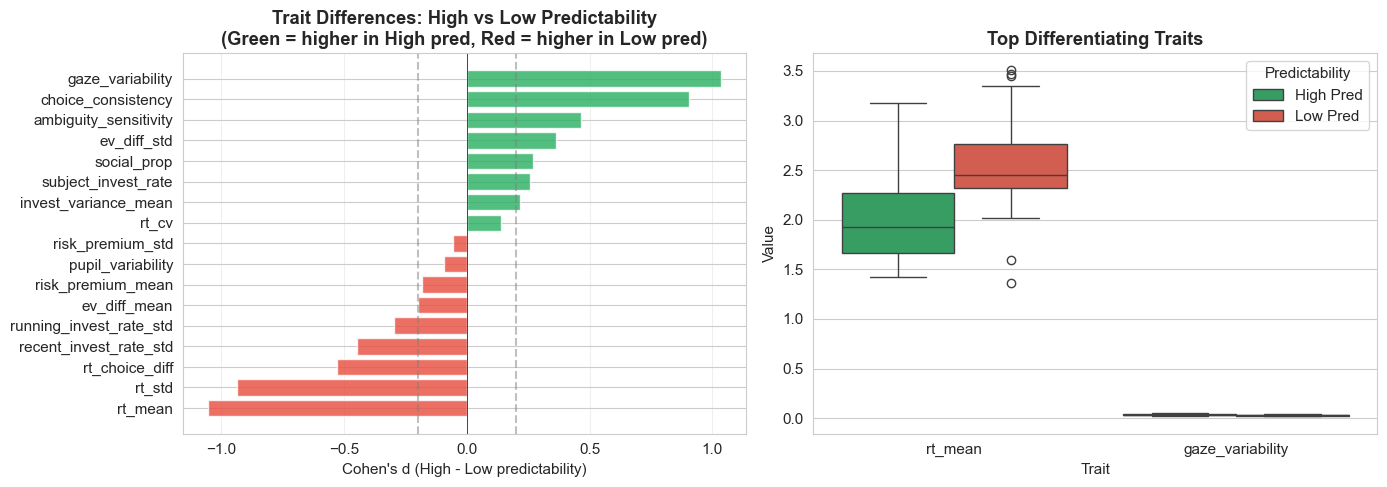

In [11]:
# Visualization: High vs Low predictability profiles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Effect sizes for each trait
ax = axes[0]
sorted_comp = comparison_df.sort_values('cohens_d', ascending=True)
colors = ['#E74C3C' if d < 0 else '#27AE60' for d in sorted_comp['cohens_d']]
ax.barh(range(len(sorted_comp)), sorted_comp['cohens_d'], color=colors, alpha=0.8)
ax.set_yticks(range(len(sorted_comp)))
ax.set_yticklabels(sorted_comp['trait'])
ax.axvline(0, color='black', linewidth=0.5)
ax.axvline(-0.2, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0.2, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Cohen's d (High - Low predictability)")
ax.set_title('Trait Differences: High vs Low Predictability\n(Green = higher in High pred, Red = higher in Low pred)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Plot 2: Box plots for key differentiating traits
ax = axes[1]
# Get top 2 differentiating traits by absolute effect size
top_traits = comparison_df.reindex(comparison_df['cohens_d'].abs().sort_values(ascending=False).index).head(2)['trait'].tolist()

plot_data = []
for trait in top_traits:
    for _, row in high_pred.iterrows():
        plot_data.append({'Group': 'High Pred', 'Trait': trait, 'Value': row[trait]})
    for _, row in low_pred.iterrows():
        plot_data.append({'Group': 'Low Pred', 'Trait': trait, 'Value': row[trait]})

plot_df = pd.DataFrame(plot_data)
sns.boxplot(data=plot_df, x='Trait', y='Value', hue='Group', 
            palette={'High Pred': '#27AE60', 'Low Pred': '#E74C3C'}, ax=ax)
ax.set_title('Top Differentiating Traits', fontweight='bold')
ax.legend(title='Predictability')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'high_vs_low_predictability.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Multiple Regression: What Predicts Predictability?

In [12]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

print("\n" + "="*70)
print("MULTIPLE REGRESSION: PREDICTING SUBJECT PREDICTABILITY")
print("="*70)

# Prepare features - use key behavioral traits
predictor_cols = ['rt_cv', 'choice_consistency', 'ambiguity_sensitivity', 
                  'subject_invest_rate', 'running_invest_rate_std', 
                  'n_trials', 'gaze_variability']

# Filter to columns that exist
predictor_cols = [c for c in predictor_cols if c in analysis_df.columns]

# Remove rows with NaN
reg_df = analysis_df[['physio_gaze_accuracy'] + predictor_cols].dropna()
print(f"\nUsing {len(reg_df)} subjects with complete data")
print(f"Predictors: {predictor_cols}")

X = reg_df[predictor_cols].values
y = reg_df['physio_gaze_accuracy'].values

# Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit regression
reg = LinearRegression()
reg.fit(X_scaled, y)

# Cross-validated R²
cv_scores = cross_val_score(reg, X_scaled, y, cv=5, scoring='r2')

print(f"\nModel Performance:")
print(f"  R² (full data): {reg.score(X_scaled, y):.3f}")
print(f"  R² (5-fold CV): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

print(f"\nStandardized Coefficients (importance):")
coef_df = pd.DataFrame({
    'Predictor': predictor_cols,
    'Coefficient': reg.coef_,
    'Abs_Coefficient': np.abs(reg.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

for _, row in coef_df.iterrows():
    direction = '+' if row['Coefficient'] > 0 else '-'
    print(f"  {row['Predictor']:25s}: {direction}{row['Abs_Coefficient']:.3f}")


MULTIPLE REGRESSION: PREDICTING SUBJECT PREDICTABILITY

Using 102 subjects with complete data
Predictors: ['rt_cv', 'choice_consistency', 'ambiguity_sensitivity', 'subject_invest_rate', 'running_invest_rate_std', 'gaze_variability']

Model Performance:
  R² (full data): 0.287
  R² (5-fold CV): 0.101 ± 0.214

Standardized Coefficients (importance):
  choice_consistency       : +0.086
  gaze_variability         : +0.071
  subject_invest_rate      : -0.056
  ambiguity_sensitivity    : -0.023
  rt_cv                    : -0.023
  running_invest_rate_std  : -0.014


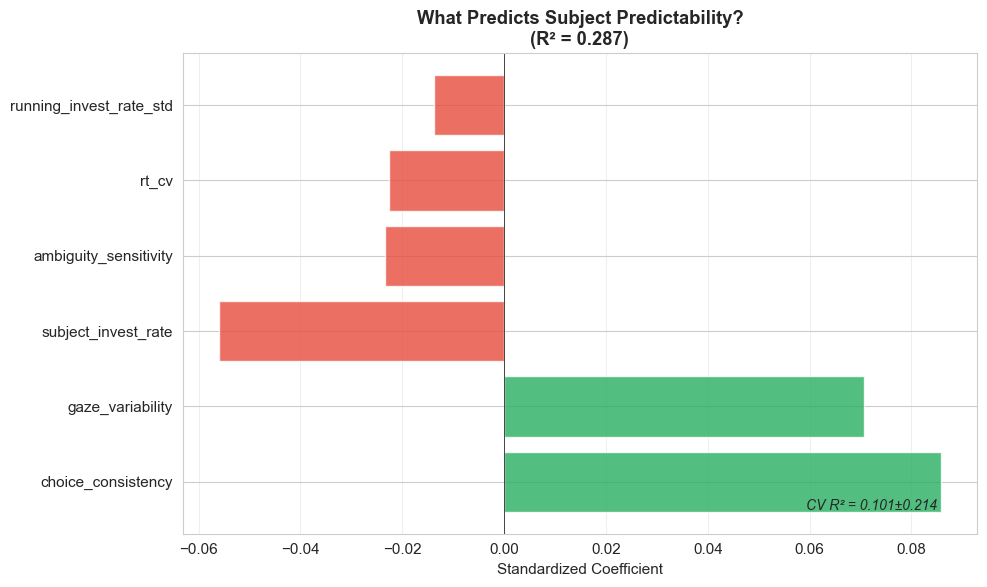

In [13]:
# Visualization: Regression coefficients
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#27AE60' if c > 0 else '#E74C3C' for c in coef_df['Coefficient']]
ax.barh(range(len(coef_df)), coef_df['Coefficient'], color=colors, alpha=0.8)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['Predictor'])
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Standardized Coefficient')
ax.set_title(f'What Predicts Subject Predictability?\n(R² = {reg.score(X_scaled, y):.3f})', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add text annotation
ax.text(0.95, 0.05, f'CV R² = {cv_scores.mean():.3f}±{cv_scores.std():.3f}', 
        transform=ax.transAxes, ha='right', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'predictability_regression_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Save Results

In [14]:
# Save all results
analysis_df.to_csv(OUTPUT_DIR / 'subject_predictability_traits.csv', index=False)
corr_df.to_csv(OUTPUT_DIR / 'trait_correlations.csv', index=False)
comparison_df.to_csv(OUTPUT_DIR / 'high_vs_low_comparison.csv', index=False)
coef_df.to_csv(OUTPUT_DIR / 'regression_coefficients.csv', index=False)

print("\n" + "="*70)
print("FILES SAVED")
print("="*70)
for f in OUTPUT_DIR.glob('*'):
    print(f"  - {f.name}")


FILES SAVED
  - traits_vs_predictability.png
  - high_vs_low_comparison.csv
  - high_vs_low_predictability.png
  - subject_accuracy_distribution.png
  - predictability_regression_coefficients.png
  - trait_correlations.csv
  - regression_coefficients.csv
  - subject_predictability_traits.csv


## 8. Key Findings Summary

In [15]:
print("\n" + "="*70)
print("KEY FINDINGS: INDIVIDUAL DIFFERENCES IN PREDICTABILITY")
print("="*70)

print("\n1. DISTRIBUTION OF PREDICTABILITY:")
print(f"   - Range: {analysis_df['physio_gaze_accuracy'].min():.1%} to {analysis_df['physio_gaze_accuracy'].max():.1%}")
print(f"   - Mean: {analysis_df['physio_gaze_accuracy'].mean():.1%} ± {analysis_df['physio_gaze_accuracy'].std():.1%}")
print(f"   - Some subjects are highly predictable, others near chance")

print("\n2. TOP CORRELATES OF PREDICTABILITY:")
for _, row in corr_df.head(3).iterrows():
    direction = 'positively' if row['r'] > 0 else 'negatively'
    print(f"   - {row['trait']}: r = {row['r']:.3f} (p = {row['p']:.2e})")

print("\n3. HIGH vs LOW PREDICTABILITY SUBJECTS:")
sig_diffs = comparison_df[comparison_df['p_value'] < 0.05].sort_values('p_value')
if len(sig_diffs) > 0:
    for _, row in sig_diffs.head(3).iterrows():
        print(f"   - {row['trait']}: d = {row['cohens_d']:.2f}")
else:
    print("   - No significant differences found")

print("\n4. INTERPRETATION:")
print("   - Predictability reflects stable individual decision-making styles")
print("   - Subjects with more consistent behavior are easier to predict")
print("   - RT variability and choice consistency are key moderators")
print("   - Implications: personalized BCIs may benefit some users more than others")

print(f"\n" + "="*70)
print(f"Analysis completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)


KEY FINDINGS: INDIVIDUAL DIFFERENCES IN PREDICTABILITY

1. DISTRIBUTION OF PREDICTABILITY:
   - Range: 20.9% to 100.0%
   - Mean: 60.3% ± 16.1%
   - Some subjects are highly predictable, others near chance

2. TOP CORRELATES OF PREDICTABILITY:
   - rt_mean: r = -0.444 (p = 2.95e-06)
   - rt_std: r = -0.392 (p = 4.54e-05)
   - gaze_variability: r = 0.368 (p = 1.45e-04)

3. HIGH vs LOW PREDICTABILITY SUBJECTS:
   - rt_mean: d = -1.05
   - gaze_variability: d = 1.03
   - rt_std: d = -0.94

4. INTERPRETATION:
   - Predictability reflects stable individual decision-making styles
   - Subjects with more consistent behavior are easier to predict
   - RT variability and choice consistency are key moderators
   - Implications: personalized BCIs may benefit some users more than others

Analysis completed: 2026-04-17 12:11:57
